<a href="https://colab.research.google.com/github/JayadharsiniMathiyalagan/Fundamentals-of-Machine-Learning/blob/main/FOML_EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Explained Variance Ratio:
 [0.72962445 0.22850762 0.03668922 0.00517871]




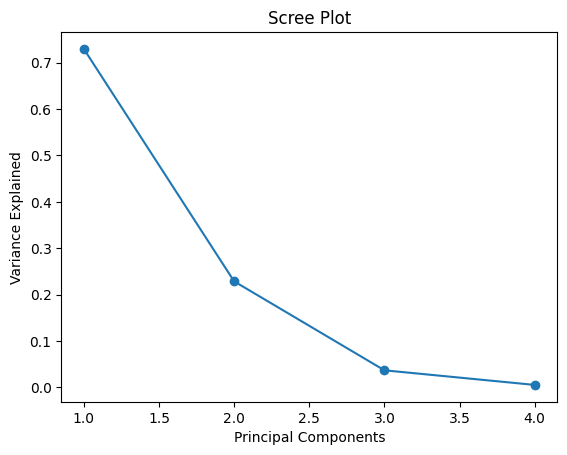

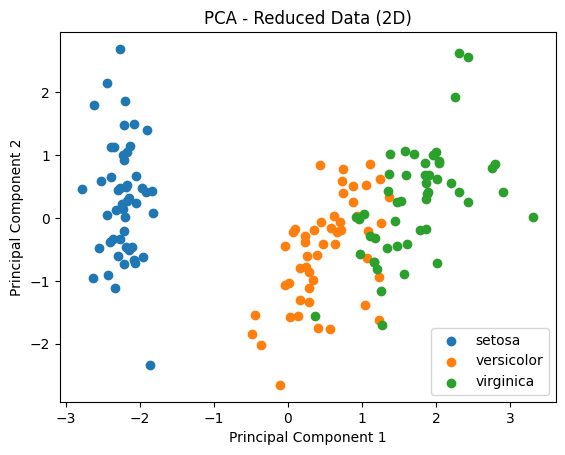

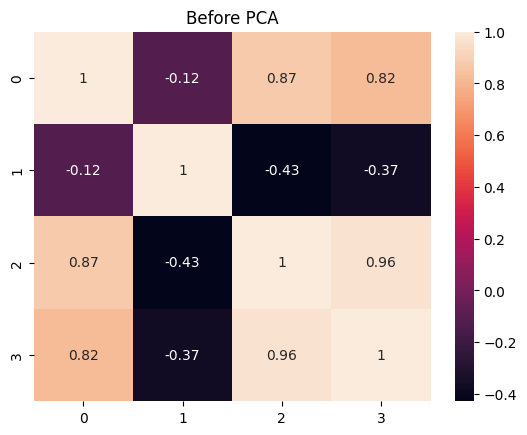

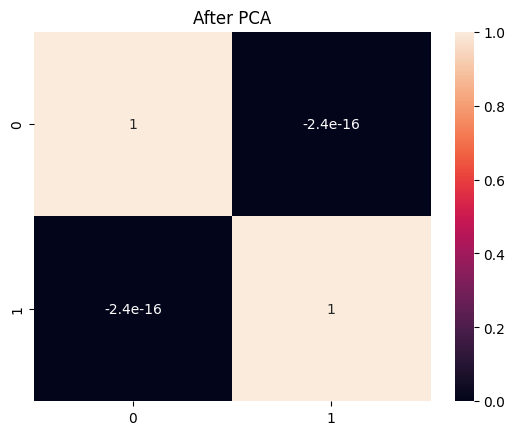

In [17]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================
# STEP 2: Load Dataset (Iris)
# ==============================
iris = datasets.load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print(df.head())

# ==============================
# STEP 3: Standardize Data
# ==============================
X = df.iloc[:, :-1]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# ==============================
# STEP 4: Apply PCA (initial)
# ==============================
pca = PCA()
pca.fit(scaled_data)

# ==============================
# STEP 5: Explained Variance
# ==============================
explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:\n", explained_variance)
print("\n")
# Scree Plot
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()
print("\n")

# ==============================
# STEP 6: Choose Components (2)
# ==============================
pca = PCA(n_components=2)

# ==============================
# STEP 7: Transform Data
# ==============================
X_pca = pca.fit_transform(scaled_data)

# ==============================
# STEP 8: Visualize Reduced Data
# ==============================
plt.figure()
print("\n")

for i in range(3):
    plt.scatter(X_pca[df['target'] == i, 0],
                X_pca[df['target'] == i, 1],
                label=iris.target_names[i])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Reduced Data (2D)")
plt.legend()
plt.show()
print("\n")

# ==============================
# STEP 9: Correlation Heatmaps
# ==============================
sns.heatmap(pd.DataFrame(scaled_data).corr(), annot=True)
plt.title("Before PCA")
plt.show()
print("\n")

sns.heatmap(pd.DataFrame(X_pca).corr(), annot=True)
plt.title("After PCA")
plt.show()